In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from datetime import datetime

# Fetch stock data
ticker = 'AAPL'
start_date = '2015-01-01'
end_date = datetime.today().strftime('%Y-%m-%d')
stock = yf.Ticker(ticker)
data = stock.history(start=start_date, end=end_date)


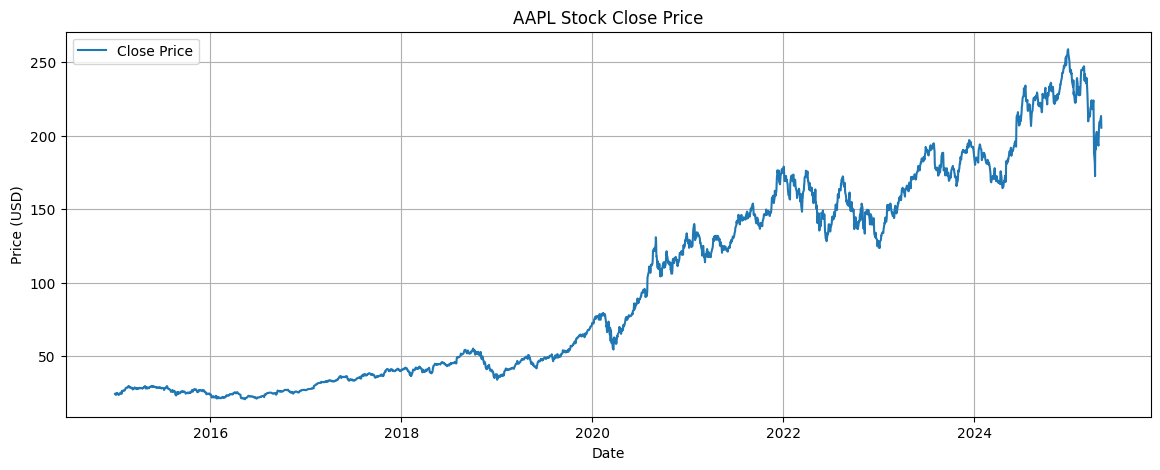

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(data.index, data['Close'], label='Close Price')
plt.title(f'{ticker} Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
data_close = data['Close'].copy()
scaler = MinMaxScaler(feature_range=(0, 1))
df1 = scaler.fit_transform(np.array(data_close).reshape(-1, 1))


In [ ]:
def create_dataset(dataset, time_step=100):
    dataX, dataY = [], []
    for i in range(len(dataset) - time_step - 1):
        dataX.append(dataset[i:(i + time_step), 0])
        dataY.append(dataset[i + time_step, 0])
    return np.array(dataX), np.array(dataY)

# Create train/test datasets
time_step = 100
training_size = int(len(df1) * 0.8)
train_data = df1[:training_size]
test_data = df1[training_size:]
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)



In [73]:
# Convert to PyTorch tensors
X_train = torch.tensor(X_train).float().unsqueeze(-1)  # [samples, time_step, 1]
y_train = torch.tensor(y_train).float()
X_test = torch.tensor(X_test).float().unsqueeze(-1)
y_test = torch.tensor(y_test).float()

# Dataset and DataLoader
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(StockDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(StockDataset(X_test, y_test), batch_size=64, shuffle=False)

# LSTM + Attention model
class LSTMWithAttention(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=50, num_layers=2):
        super(LSTMWithAttention, self).__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.attn_fc = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, 1)

    def attention(self, lstm_output):
        # lstm_output: [batch, seq_len, hidden_dim]
        attn_weights = torch.softmax(self.attn_fc(lstm_output), dim=1)  # [batch, seq_len, 1]
        context = torch.sum(attn_weights * lstm_output, dim=1)  # [batch, hidden_dim]
        return context

    def forward(self, x):
        lstm_out, _ = self.lstm(x)  # [batch, seq_len, hidden_dim]
        context = self.attention(lstm_out)  # [batch, hidden_dim]
        out = self.fc(context)  # [batch, 1]
        return out.squeeze()  # [batch]

# Initialize model, loss, and optimizer
model = LSTMWithAttention()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 200
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {total_loss/len(train_loader)*10000:.6f}")


Epoch 1/200, Loss: 493.863316
Epoch 2/200, Loss: 176.175619
Epoch 3/200, Loss: 24.628346
Epoch 4/200, Loss: 13.412510
Epoch 5/200, Loss: 12.383462
Epoch 6/200, Loss: 12.391732
Epoch 7/200, Loss: 12.400278
Epoch 8/200, Loss: 11.765034
Epoch 9/200, Loss: 11.899622
Epoch 10/200, Loss: 12.291906
Epoch 11/200, Loss: 11.738466
Epoch 12/200, Loss: 11.594414
Epoch 13/200, Loss: 12.050601
Epoch 14/200, Loss: 11.916162
Epoch 15/200, Loss: 11.430733
Epoch 16/200, Loss: 11.268750
Epoch 17/200, Loss: 11.486837
Epoch 18/200, Loss: 11.653645
Epoch 19/200, Loss: 12.080670
Epoch 20/200, Loss: 11.837995
Epoch 21/200, Loss: 11.349120
Epoch 22/200, Loss: 11.436439
Epoch 23/200, Loss: 11.307274
Epoch 24/200, Loss: 11.604456
Epoch 25/200, Loss: 11.787822
Epoch 26/200, Loss: 12.121090
Epoch 27/200, Loss: 10.946155
Epoch 28/200, Loss: 11.107760
Epoch 29/200, Loss: 11.146617
Epoch 30/200, Loss: 10.992903
Epoch 31/200, Loss: 11.268183
Epoch 32/200, Loss: 12.709641
Epoch 33/200, Loss: 11.580107
Epoch 34/200, Los

In [78]:
torch.save(model.state_dict(), 'lstm_attention_model.pth')
print("Model saved successfully.")


Model saved successfully.


In [74]:
model.eval()

# Collect predictions
predicted = []
actual = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        output = model(X_batch)
        predicted.extend(output.numpy())
        actual.extend(y_batch.numpy())

# Inverse transform to original scale
predicted = scaler.inverse_transform(np.array(predicted).reshape(-1, 1))
actual = scaler.inverse_transform(np.array(actual).reshape(-1, 1))

In [75]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(actual, predicted))
print(f'RMSE of the model: {rmse:.4f}')


RMSE of the model: 6.6702


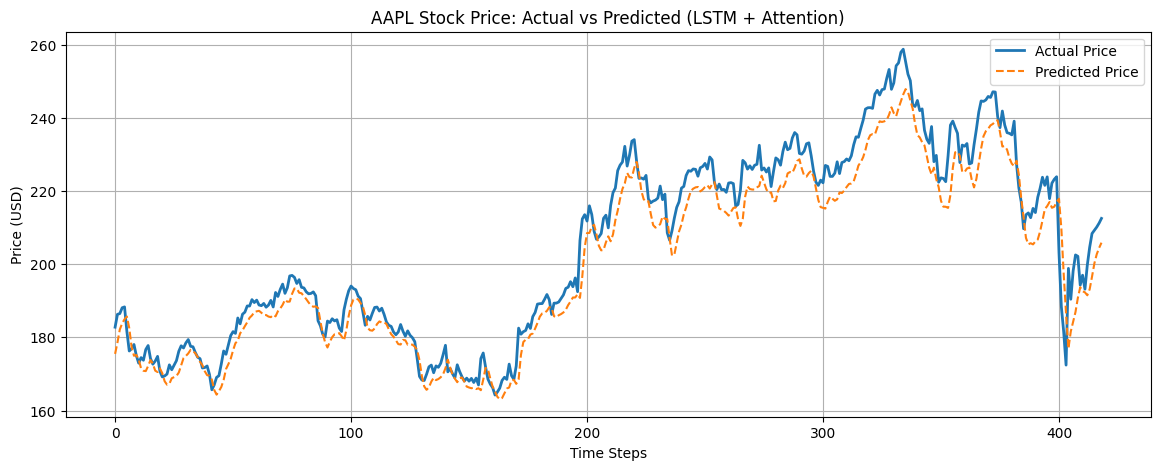

In [76]:
# Plotting
plt.figure(figsize=(14, 5))
plt.plot(actual, label='Actual Price', linewidth=2)
plt.plot(predicted, label='Predicted Price', linestyle='--')
plt.title(f'{ticker} Stock Price: Actual vs Predicted (LSTM + Attention)')
plt.xlabel('Time Steps')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.savefig('lstm_attention_prediction.png')
plt.show()

In [77]:
start_index = len(train_data) + time_step + 1  # skip initial offset

# Get corresponding dates
dates = data.index[start_index:start_index + len(predicted)]

# Create DataFrame
results_df = pd.DataFrame({
    'Date': dates,
    'Actual': actual.flatten(),
    'Predicted': predicted.flatten()
})

# Save to CSV
results_df.to_csv('actual_vs_predicted.csv', index=False)